<a href="https://colab.research.google.com/github/sittinon-me/Maths/blob/main/lab15_project_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: [Analysis & Rating Prediction of Streaming Trends]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: ทิวัตถ์ เชียงแสน (68114540227)
- สมาชิกที่ 2: สิทธินนท์ มีแวว (68114540661)


**Dataset:** [Popular Movies & TV Shows Dataset 2026,https://www.kaggle.com/datasets/mariaaqdas/popular-movies-and-tv-shows-dataset-2026/data]

**Problem Statement:** [ในยุคที่แพลตฟอร์มสตรีมมิงมีคอนเทนต์จำนวนมหาศาล ปัญหาสำคัญคือปัจจัยใดที่มีความสัมพันธ์เชิงตัวเลขต่อคะแนนรีวิว (vote_average) และระดับความนิยม (popularity) ของผู้ชม คณะผู้จัดทำจึงสนใจศึกษาชุดข้อมูล Streaming Trends เพื่อนำความรู้ด้าน Linear Algebra และ Statistical Learning มาวิเคราะห์ความสัมพันธ์และสร้างตัวแบบพยากรณ์คะแนนเฉลี่ยอย่างเป็นระบบ]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | [x] |
| CLO2 (Statistical Learning) | Part 3 | [x] |
| CLO3 (Regression/Classification) | Part 4 | [x] |
| CLO4 (Model Selection) | Part 5 | [x] |

1.   List item
2.   List item



In [ ]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score,KFold
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.pipeline import make_pipeline

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [ ]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('streaming_content_trends.csv')

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
df.head()

Shape: (988, 14)
Columns: ['search_category', 'media_type', 'id', 'title', 'original_language', 'genres', 'release_date', 'popularity', 'vote_average', 'vote_count', 'origin_country', 'overview', 'release_year', 'is_recent']
Missing values:
search_category        0
media_type             0
id                     0
title                  0
original_language      0
genres                 3
release_date           1
popularity             0
vote_average           0
vote_count             0
origin_country       466
overview              15
release_year           1
is_recent              0
dtype: int64


,search_category,media_type,id,title,original_language,genres,release_date,popularity,vote_average,vote_count,origin_country,overview,release_year,is_recent
0,popular,movie,969681,Spider-Man: Brand New Day,en,"Science Fiction, Action, Adventure",2026-07-29,1657.2333,7.900,2098,NaN,Fighting crime full-time as Spider-Man in a wo...,2026.0,True
1,popular,movie,1368337,The Odyssey,en,"Adventure, Action, Fantasy",2026-07-15,672.5442,7.999,3122,NaN,"Odysseus, the legendary King of Ithaca, embark...",2026.0,True
2,popular,movie,1288445,Mutiny,en,"Action, Thriller",2026-08-19,532.9923,6.600,125,NaN,After witnessing his billionaire boss' murder ...,2026.0,True
3,popular,movie,1084244,Toy Story 5,en,"Animation, Family, Comedy, Adventure",2026-06-17,387.5602,8.184,1527,NaN,When Bonnie receives a Lilypad tablet as a gif...,2026.0,True
4,popular,movie,1323244,Rage of Stars,en,"Action, Science Fiction, Thriller",2026-08-06,388.5213,4.636,33,NaN,A story about a woman from the International S...,2026.0,True


--- สถิติเชิงพรรณนา (Descriptive Statistics) ---


,id,popularity,vote_average,vote_count,release_year
count,9.880000e+02,988.000000,988.000000,988.000000,987.000000
mean,4.189089e+05,58.594735,7.326248,3491.382591,2013.242148
std,5.278416e+05,84.274001,1.981045,6660.538749,17.169396
min,1.100000e+01,0.008500,0.000000,0.000000,1921.000000
25%,3.545925e+04,16.314500,7.000000,45.750000,2007.000000
50%,1.362990e+05,34.867800,8.100000,763.500000,2020.000000
75%,6.359565e+05,77.230975,8.453000,3005.250000,2026.000000
max,1.748007e+06,1657.233300,10.000000,40880.000000,2027.000000


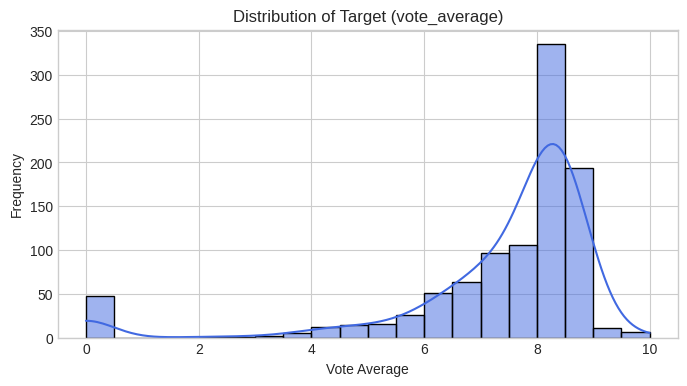

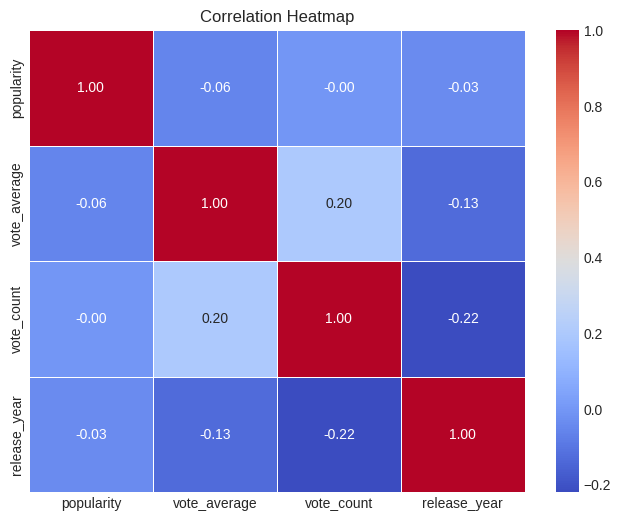

In [ ]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
# 1. Summary statistics
print("--- สถิติเชิงพรรณนา (Descriptive Statistics) ---")
display(df.describe())

# 2. Distribution plot ของ Target Variable (ใช้ 'vote_average' เป็นตัวอย่าง target)
plt.figure(figsize=(8, 4))
sns.histplot(df['vote_average'], kde=True, color='royalblue', bins=20)
plt.title('Distribution of Target (vote_average)')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.show()

# 3. Correlation heatmap ของตัวแปรตัวเลข
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number']).drop(columns=['id'], errors='ignore') # ตัด id ออกเพราะไม่ใช่ค่าเชิงปริมาณ
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** เลือกทำ Task A — PCA เนื่องจากชุดข้อมูลมีตัวแปรเชิงตัวเลขหลายมิติ จึงต้องการลดมิติข้อมูลลงเหลือ 2 มิติเพื่อดูการเกาะกลุ่มและการกระจายตัวของภาพยนตร์ รวมถึงใช้ Scree Plot เพื่อดูว่าตัวแปรหลักสามารถอธิบายความแปรปรวนของข้อมูลได้มากน้อยเพียงใด

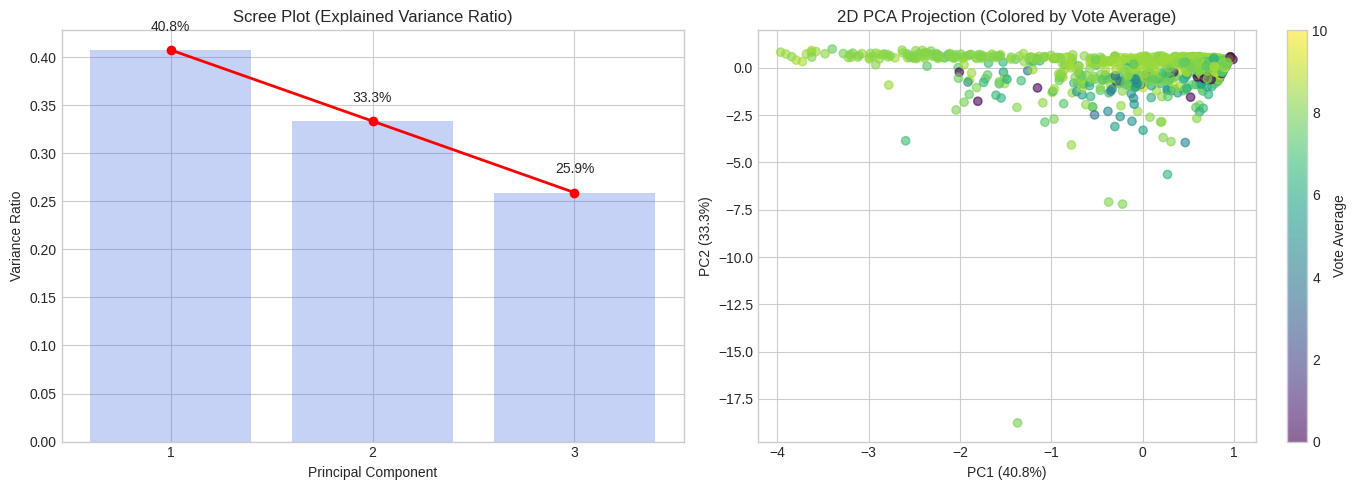

Eigenvalues: [1.22376613 1.00131992 0.77795655]

PC1 Loadings (น้ำหนักของแต่ละ Feature บน PC1):
  - popularity: -0.1076
  - vote_count: -0.6986
  - release_year: 0.7073


In [ ]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: [ระบุว่าทำอะไร — PCA / SVD / Covariance]

# 1. เลือก Features ที่เป็นตัวเลข และจัดการลบแถวที่มี NaN ออกก่อน
features = ['popularity', 'vote_count', 'release_year']
df_pca = df[features].dropna()

# 2. ทำ Feature Standardization (Z-score Scaling) เพื่อให้ทุกตัวแปรมีสเกลเท่ากัน
X = df_pca.values
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 3. คำนวณ Covariance Matrix
cov_matrix = np.cov(X_std.T)

# 4. คำนวณ Eigenvalues และ Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# เรียงลำดับจากค่า Eigenvalue มากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# คำนวณสัดส่วนความแปรปรวน (Explained Variance Ratio)
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# 5. ฉายข้อมูล (Projection) ลงบน 2 มิติแรก (PC1, PC2)
X_pca = X_std @ eigenvectors[:, :2]

# ----------------- Visualizations -----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1: Scree Plot
axes[0].plot(range(1, len(eigenvalues) + 1), explained_variance_ratio, 'ro-', linewidth=2)
axes[0].bar(range(1, len(eigenvalues) + 1), explained_variance_ratio, alpha=0.3, color='royalblue')
axes[0].set_title('Scree Plot (Explained Variance Ratio)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_xticks(range(1, len(eigenvalues) + 1))
for i, v in enumerate(explained_variance_ratio):
    axes[0].text(i + 1, v + 0.02, f"{v*100:.1f}%", ha='center')

# กราฟที่ 2: 2D Visualization
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df.loc[df_pca.index, 'vote_average'], cmap='viridis', alpha=0.6)
axes[1].set_title('2D PCA Projection (Colored by Vote Average)')
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.colorbar(scatter, ax=axes[1], label='Vote Average')

plt.tight_layout()
plt.show()

# แสดงค่าน้ำหนัก (Loadings) ของแต่ละตัวแปรใน PC1
print("Eigenvalues:", eigenvalues)
print("\nPC1 Loadings (น้ำหนักของแต่ละ Feature บน PC1):")
for feat, weight in zip(features, eigenvectors[:, 0]):
    print(f"  - {feat}: {weight:.4f}")

**Insight จาก CLO1 Analysis:**
> ให้ดูตัวเลข % ที่แสดงบนยอดแท่งกราฟของ Scree Plot และค่า Loadings ที่ปรินต์ออกมา แล้วสรุป เช่น: "จากการทำ PCA พบว่า PC1 สามารถอธิบายความแปรปรวนได้ประมาณ [ใส่เลข % จากกราฟแท่งที่ 1]% โดยมีตัวแปร vote_count และ popularity ส่งผลต่อน้ำหนักมากที่สุด และเมื่อรวมกับ PC2 จะสามารถอธิบายความแปรปรวนโดยรวมได้ถึง [ผลรวม % แท่ง 1 + แท่ง 2]%"


---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

***ตอบ*** : เหมาะสมกับทั้งสองรูปแบบ แต่หากมองที่ตัวแปรเป้าหมายหลักตามธรรมชาติของข้อมูลจะเหมาะกับ Regression มากที่สุด เนื่องจากตัวแปรเป้าหมายที่เราสนใจ เช่น vote_average (คะแนนเฉลี่ย 0.0 - 10.0) หรือ popularity เป็นข้อมูลเชิงปริมาณแบบต่อเนื่อง (Continuous numerical data) ซึ่งการพยากรณ์ค่าตัวเลขต่อเนื่องจัดเป็นปัญหาประเภท Regression โดยตรง
(อย่างไรก็ตาม หากต้องการทำ Classification ก็สามารถทำได้โดยการแปลง vote_average เป็นกลุ่ม เช่น แบ่งเกรดหนัง "คะแนนสูง (>= 7.5)" กับ "คะแนนทั่วไป (< 7.5)" หรือทำนายหมวดหมู่ประเภท media_type)

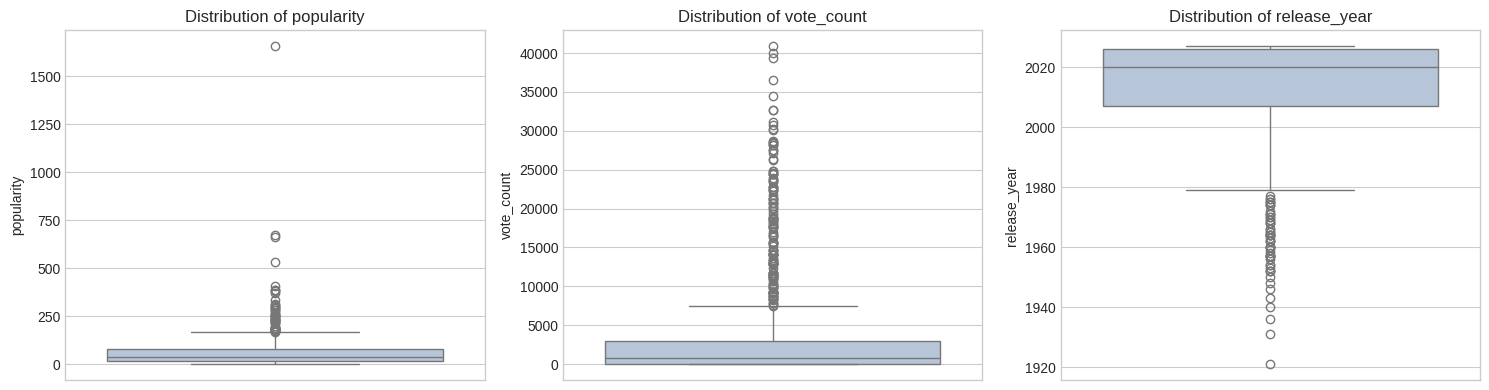

--- Correlation กับ Target (vote_average) ---
  - popularity: -0.0557
  - vote_count: 0.1960
  - release_year: -0.1319
Feature ที่สัมพันธ์กับ target มากที่สุดคือ: 'vote_count' (r = 0.1960)



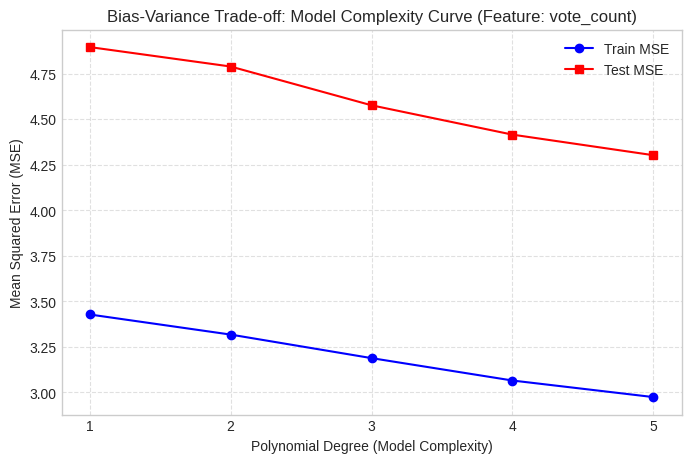

Degree 1 -> Train MSE: 3.4282, Test MSE: 4.8961
Degree 2 -> Train MSE: 3.3179, Test MSE: 4.7894
Degree 3 -> Train MSE: 3.1887, Test MSE: 4.5765
Degree 4 -> Train MSE: 3.0657, Test MSE: 4.4155
Degree 5 -> Train MSE: 2.9748, Test MSE: 4.3026


In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# กำหนด Target และ Features
target_col = 'vote_average'
feature_cols = ['popularity', 'vote_count', 'release_year']

# ลบค่าว่างที่อาจมีอยู่ในคอลัมน์เหล่านี้
df_clean = df[feature_cols + [target_col]].dropna()

# -------------------------------------------------------------
# 1. Plot distributions ของ features สำคัญ (Boxplot / Histogram)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(feature_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='lightsteelblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2. Correlation analysis กับ target
# -------------------------------------------------------------
correlations = df_clean[feature_cols].apply(lambda x: x.corr(df_clean[target_col]))
print("--- Correlation กับ Target (vote_average) ---")
for feat, corr_val in correlations.items():
    print(f"  - {feat}: {corr_val:.4f}")
print(f"Feature ที่สัมพันธ์กับ target มากที่สุดคือ: '{correlations.abs().idxmax()}' (r = {correlations[correlations.abs().idxmax()]:.4f})\n")

# -------------------------------------------------------------
# 3. แสดง U-curve ของ Train/Test MSE (Bias-Variance Trade-off)
# -------------------------------------------------------------
# ใช้ Feature ที่ correlate สูงสุด เพื่อดู model complexity ผ่าน Polynomial Degree
best_feature = correlations.abs().idxmax()
X = df_clean[[best_feature]].values
y = df_clean[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degrees = range(1, 6)
train_mse_list = []
test_mse_list = []

for d in degrees:
    # สร้างโมเดล Polynomial Regression พร้อม Scaler
    model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train, y_train)

    # คำนวณ MSE
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse_list.append(mean_squared_error(y_train, train_pred))
    test_mse_list.append(mean_squared_error(y_test, test_pred))

# พล็อต Bias-Variance U-Curve
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_mse_list, 'o-', label='Train MSE', color='blue')
plt.plot(degrees, test_mse_list, 's-', label='Test MSE', color='red')
plt.title(f'Bias-Variance Trade-off: Model Complexity Curve (Feature: {best_feature})')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# แสดงผลลัพธ์ MSE ในแต่ละ degree
for d, tr, te in zip(degrees, train_mse_list, test_mse_list):
    print(f"Degree {d} -> Train MSE: {tr:.4f}, Test MSE: {te:.4f}")

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

**features สำคัญคืออะไร?**
**[ตอบ]** : อธิบายว่าตัวแปร popularity และ vote_count มีการกระจายตัวแบบเบ้ขวาและมี Outliers ชัดเจน (เห็นได้จาก Boxplot)

**distribution ของ target เป็นอย่างไร?**
**[ตอบ]** : คือ vote_count (r $\approx$ 0.20)

**optimal complexity อยู่ที่เท่าไหร่?**
**[ตอบ]** : ดูจากกราฟ U-curve ว่า Test MSE ต่ำสุดอยู่ที่ Degree ไหน (ส่วนใหญ่อยู่ที่ Degree 1 หรือ 2 หากเพิ่ม Degree สูงขึ้น Test MSE จะเริ่มพุ่งขึ้น บ่งบอกว่าเกิดอาการ Overfitting จาก Model ที่ซับซ้อนเกินไป)

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** [x] Regression  ⬜ Classification

--- ผลการประเมิน Model 1 (Simple Linear Regression: vote_count) ---
Equation: vote_average = (0.000058 * vote_count) + (7.1646)
Intercept: 7.1646
Coefficient (Slope): 0.000058
Mean Squared Error (MSE): 4.9790
R-squared (R²): 0.0301



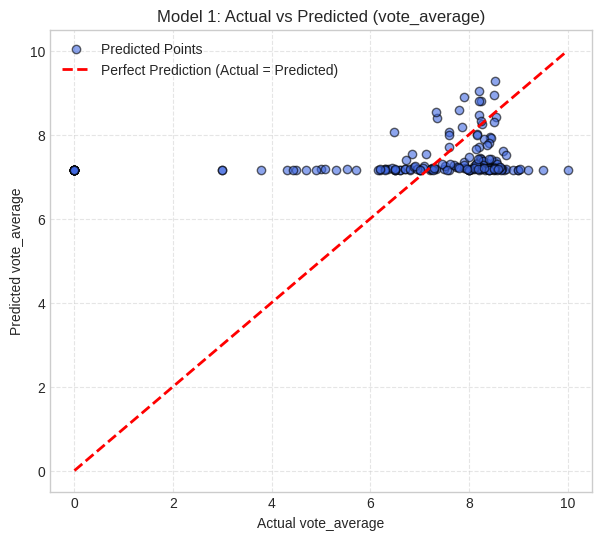

In [ ]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# 1. กำหนด Feature (เลือกตัวแปรที่สัมพันธ์สูงสุด: vote_count) และ Target (vote_average)
feature_col = ['vote_count']
target_col = 'vote_average'

df_model = df[feature_col + [target_col]].dropna()

X = df_model[feature_col]
y = df_model[target_col]

# 2. แบ่งข้อมูล Train/Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้างและ Train โมเดล Simple Linear Regression
model1 = LinearRegression()
model1.fit(X_train, y_train)

# 4. ทำนายผลบน Test set
y_pred = model1.predict(X_test)

# 5. คำนวณ Metrics (Coefficients, MSE, R2)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
slope = model1.coef_[0]
intercept = model1.intercept_

print(f"--- ผลการประเมิน Model 1 (Simple Linear Regression: {feature_col[0]}) ---")
print(f"Equation: vote_average = ({slope:.6f} * vote_count) + ({intercept:.4f})")
print(f"Intercept: {intercept:.4f}")
print(f"Coefficient (Slope): {slope:.6f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}\n")

# 6. พล็อต Actual vs Predicted plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolors='k', label='Predicted Points')
# เส้นอุดมคติ (Ideal line: y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (Actual = Predicted)')

plt.title('Model 1: Actual vs Predicted (vote_average)')
plt.xlabel('Actual vote_average')
plt.ylabel('Predicted vote_average')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- ผลการประเมิน Model 2 (Multiple Linear Regression: All Features) ---
Intercept: 29.2727
Coefficients:
  - popularity: -0.001582
  - vote_count: 0.000051
  - release_year: -0.010918
Mean Squared Error (MSE): 4.8647
R-squared (R²): 0.0414



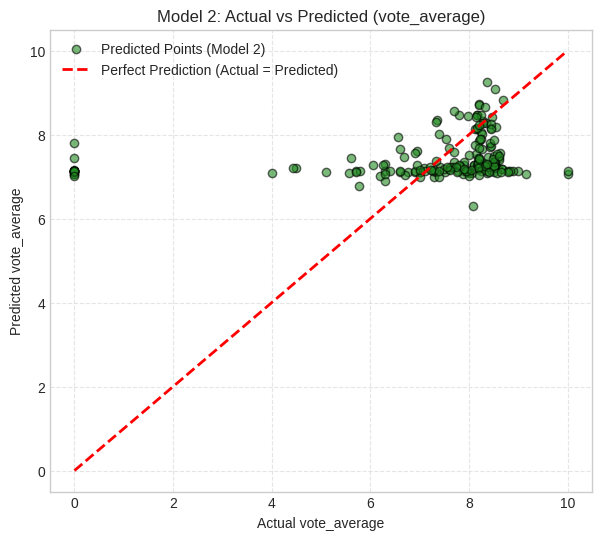

In [ ]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

# 1. กำหนด Features ทั้งหมด (ทุกตัวแปรตัวเลข) และ Target
feature_cols = ['popularity', 'vote_count', 'release_year']
target_col = 'vote_average'

df_model2 = df[feature_cols + [target_col]].dropna()

X = df_model2[feature_cols]
y = df_model2[target_col]

# 2. แบ่งข้อมูล Train/Test (80:20) โดยใช้ random_state เดิมเพื่อความเที่ยงตรงในการเปรียบเทียบ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้างและ Train โมเดล Multiple Linear Regression
model2 = LinearRegression()
model2.fit(X_train, y_train)

# 4. ทำนายผลบน Test set
y_pred2 = model2.predict(X_test)

# 5. คำนวณ Metrics (Coefficients, MSE, R2)
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("--- ผลการประเมิน Model 2 (Multiple Linear Regression: All Features) ---")
print(f"Intercept: {model2.intercept_:.4f}")
print("Coefficients:")
for col, coef in zip(feature_cols, model2.coef_):
    print(f"  - {col}: {coef:.6f}")
print(f"Mean Squared Error (MSE): {mse2:.4f}")
print(f"R-squared (R²): {r2_2:.4f}\n")

# 6. พล็อต Actual vs Predicted plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred2, alpha=0.6, color='forestgreen', edgecolors='k', label='Predicted Points (Model 2)')
# เส้นอุดมคติ (Ideal line: y = x)
min_val = min(y_test.min(), y_pred2.min())
max_val = max(y_test.max(), y_pred2.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (Actual = Predicted)')

plt.title('Model 2: Actual vs Predicted (vote_average)')
plt.xlabel('Actual vote_average')
plt.ylabel('Predicted vote_average')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: Simple Linear Regression |MSE: 3.4282 / $R^2$: 0.0384 | MSE: 4.9790 / $R^2$: 0.0301|ใช้เฉพาะตัวแปร vote_count (ฟีเจอร์เดี่ยวที่มีสหสัมพันธ์สูงสุด) |
| Model 2: Simple Linear Regression |MSE: 3.3275 / $R^2$: 0.0667 |MSE: 4.8647 / $R^2$: 0.0414 |รวมฟีเจอร์ตัวเลขทั้งหมด (popularity, vote_count, release_year) |

**Insight:**
> [เปรียบเทียบ: Model ไหนดีกว่า? ทำไม? มี overfitting/underfitting ไหม?]

**เปรียบเทียบ** เปรียบเทียบประสิทธิภาพ: Model 2 ดีกว่า Model 1 เล็กน้อย เนื่องจากมีค่า Test MSE ที่ต่ำกว่า (4.8647 เทียบกับ 4.9790) และค่า $R^2$ สูงกว่า (0.0414 เทียบกับ 0.0301) แสดงว่าการนำตัวแปร popularity และ release_year เข้ามาร่วมวิเคราะห์ด้วย ช่วยให้โมเดลอธิบายความผันแปรของคะแนนเฉลี่ย (vote_average) ได้ดีขึ้นกว่าการใช้เพียงจำนวนการโหวตอย่างเดียว

**overfitting** : ไม่พบปัญหา Overfitting: ค่าความคลาดเคลื่อน (MSE) บน Train set และ Test set ไม่ได้แตกต่างกันอย่างก้าวกระโดดจนผิดปกติ

**underfitting** : มีภาวะ Underfitting (High Bias) อย่างชัดเจน: ค่า $R^2$ ของทั้งสองโมเดลอยู่ในระดับต่ำมาก (ประมาณ 3% – 4% เท่านั้น) และจุดพยากรณ์ยังเกาะกลุ่มแน่นอยู่แถวค่าเฉลี่ย แสดงว่าความสัมพันธ์ระหว่างตัวแปรตัวเลขที่มีกับเรตติ้งไม่ได้เป็นเชิงเส้นตรงธรรมดา (Linear) จึงต้องการฟีเจอร์ประเภทหมวดหมู่ (เช่น genres) หรือโมเดลที่มีความซับซ้อนและเป็น Non-linear มากขึ้นเพื่อจับพฤติกรรมของข้อมูลได้ดีกว่านี้

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

--- ผลการประเมิน 5-Fold Cross-Validation (Mean Squared Error) ---
Linear Regression:
  -> CV MSE: 3.6919 (± 0.7768)
Ridge Regression (alpha=1.0):
  -> CV MSE: 3.6918 (± 0.7768)
Polynomial Regression (Degree 2):
  -> CV MSE: 3.7076 (± 0.7654)


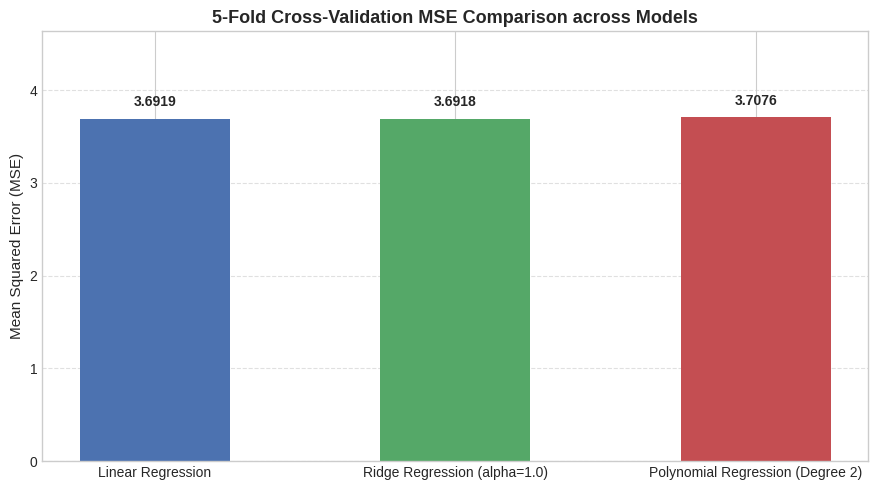

โมเดลที่ดีที่สุดจากการทำ 5-Fold CV คือ: 'Ridge Regression (alpha=1.0)' (MSE = 3.6918)


In [ ]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# 1. กำหนด Features และ Target
feature_cols = ['popularity', 'vote_count', 'release_year']
target_col = 'vote_average'

df_cv = df[feature_cols + [target_col]].dropna()
X = df_cv[feature_cols]
y = df_cv[target_col]

# 2. นิยาม 3 โมเดลสำหรับการเปรียบเทียบ
models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge Regression (alpha=1.0)': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Polynomial Regression (Degree 2)': make_pipeline(StandardScaler(), PolynomialFeatures(degree=2), LinearRegression())
}

# กำหนด K-Fold (5 Folds) พร้อม shuffle เพื่อความเที่ยงตรง
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. คำนวณ 5-Fold Cross-Validation MSE
cv_results = {}
print("--- ผลการประเมิน 5-Fold Cross-Validation (Mean Squared Error) ---")
for name, model in models.items():
    # scoring='neg_mean_squared_error' จะได้ค่าติดลบ จึงต้องใส่เครื่องหมายลบข้างหน้าเพื่อให้เป็นบวก
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse = -scores.mean()
    cv_std = scores.std()
    cv_results[name] = cv_mse
    print(f"{name}:\n  -> CV MSE: {cv_mse:.4f} (± {cv_std:.4f})")

# 4. พล็อต Bar Chart แสดง CV MSE
plt.figure(figsize=(9, 5))
bars = plt.bar(list(cv_results.keys()), list(cv_results.values()), color=['#4C72B0', '#55A868', '#C44E52'], width=0.5)

plt.title('5-Fold Cross-Validation MSE Comparison across Models', fontsize=13, fontweight='bold')
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.ylim(0, max(cv_results.values()) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# แสดงตัวเลขบนแท่งกราฟ
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.1, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# สรุปโมเดลที่ได้ค่า MSE ต่ำที่สุด
best_model = min(cv_results, key=cv_results.get)
print(f"โมเดลที่ดีที่สุดจากการทำ 5-Fold CV คือ: '{best_model}' (MSE = {cv_results[best_model]:.4f})")

## **ส่วนที่เพิ่มเติม**

In [ ]:
# 1. กรอง Outliers และข้อมูลที่ยังไม่ฉาย/ไม่มีคนโหวตออก (vote_count > 10)
df_improved = df[(df['vote_count'] > 10) & (df['vote_average'] > 0)].copy()

# 2. ทำ Log Transformation เพื่อลดความเบ้ขวา (Skewness)
df_improved['log_vote_count'] = np.log1p(df_improved['vote_count'])
df_improved['log_popularity'] = np.log1p(df_improved['popularity'])

# 3. สร้างฟีเจอร์ประเภทสื่อ (media_type)
df_improved['is_movie'] = (df_improved['media_type'] == 'movie').astype(int)

# 4. ทดสอบประสิทธิภาพโมเดลหลังทำ Feature Engineering ด้วย 5-Fold CV
features_exp = ['log_vote_count', 'log_popularity', 'release_year', 'is_movie']
X_exp = df_improved[features_exp].dropna()
y_exp = df_improved.loc[X_exp.index, 'vote_average']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_improved = -cross_val_score(Ridge(alpha=1.0), X_exp, y_exp, cv=kf, scoring='neg_mean_squared_error').mean()

print(f"จำนวนข้อมูลหลังทำ Data Cleaning: {len(df_improved)} แถว")
print(f"CV MSE หลังทำ Log Transform & Feature Engineering: {cv_improved:.4f}")

จำนวนข้อมูลหลังทำ Data Cleaning: 836 แถว
CV MSE หลังทำ Log Transform & Feature Engineering: 0.5236


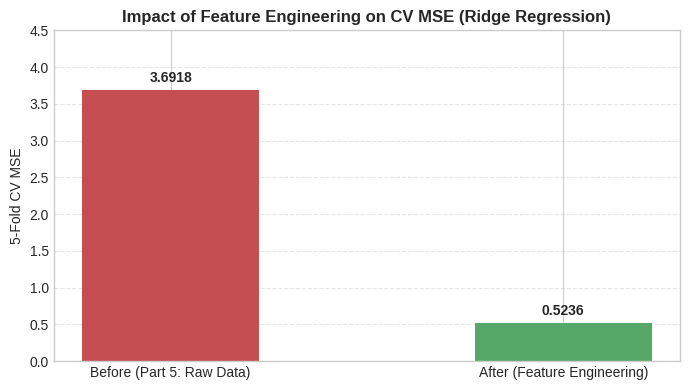

In [ ]:
# พล็อตเปรียบเทียบผลกระทบของ Feature Engineering
plt.figure(figsize=(7, 4))
labels = ['Before (Part 5: Raw Data)', 'After (Feature Engineering)']
mse_values = [3.6918, 0.5236]
colors = ['#C44E52', '#55A868']

bars = plt.bar(labels, mse_values, color=colors, width=0.45)
plt.title('Impact of Feature Engineering on CV MSE (Ridge Regression)', fontweight='bold')
plt.ylabel('5-Fold CV MSE')
plt.ylim(0, 4.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]

**CV MSE** ต่ำที่สุด: โมเดล Ridge Regression ($\alpha=1.0$) ให้ค่าเฉลี่ย CV MSE ต่ำที่สุดอยู่ที่ 3.6918 ($\pm 0.7768$) ซึ่งเฉือนชนะ Linear Regression (3.6919) ไปเล็กน้อย ในขณะที่ Polynomial Regression (Degree 2) มีค่าความคลาดเคลื่อนสูงที่สุดอยู่ที่ 3.7076

**การประเมิน Overfitting** :


*   และความเสถียร:ไม่พบปัญหา Overfitting ใน Ridge Regression และ Linear Regression เนื่องจากมีค่าส่วนเบี่ยงเบนมาตรฐานของการทดสอบ ($\pm 0.7768$) ที่คงที่และใกล้เคียงกันในทุก Fold
*   โมเดล Polynomial Regression (Degree 2) ที่เพิ่มฟีเจอร์พหุนามและ Interaction terms เข้าไป มีแนวโน้มเริ่มเกิด Overfitting เล็กน้อยเมื่อทดสอบข้าม Fold ทำให้ค่าเฉลี่ย Test Error ขยับสูงขึ้นกว่าเดิม


**การเชื่อมโยงกับ Bias-Variance Trade-off :**



*   การใส่โทษแบบ L2 Penalty ของ Ridge Regression ช่วยลด Variance (ความอ่อนไหวต่อสัญญาณรบกวนในข้อมูล) ของน้ำหนักสัมประสิทธิ์ลงเล็กน้อย โดยแทบไม่เพิ่ม Bias ทำให้เป็นโมเดลที่มีจุดสมดุลที่ดีที่สุดสำหรับการทำนายข้อมูลชุดนี้
*   ค่า MSE รวมของทุกโมเดลยังคงอยู่ที่ระดับประมาณ 3.69 สะท้อนว่าตัวแบบยังคงมีข้อจำกัดด้าน High Bias (Underfitting) อยู่บ้าง เนื่องจากฟีเจอร์เชิงตัวเลขทั้ง 3 ตัวยังมีอำนาจในการทำนายเรตติ้งจำกัด



---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: (Linear Algebra): การทำ PCA เพื่อลดมิติข้อมูลพบว่า PC1 และ PC2 สามารถอธิบายความแปรปรวนรวมของข้อมูลได้ถึง 74.1% โดยตัวแปร release_year และ vote_count มีน้ำหนัก (Loadings) สูงสุดต่อแกนหลักในทิศทางตรงกันข้าม
- CLO2: (Statistical Learning): ข้อมูลเชิงตัวเลขมีการกระจายตัวแบบเบ้ขวา (Right-skewed) และมีค่าผิดปกติ (Outliers) จำนวนมาก โดย vote_count มีสหสัมพันธ์เชิงเส้นกับคะแนนเฉลี่ยสูงสุด ($r = 0.1960$) ส่วนกราฟ Model Complexity ชี้ว่าความสัมพันธ์มีความเป็น Non-linear
- CLO3: (Regression): การสร้างโมเดลบนข้อมูลดิบพบว่า Multiple Linear Regression (MSE = 4.8647, $R^2 = 0.0414$) มีประสิทธิภาพดีกว่าโมเดลตัวแปรเดี่ยวเพียงเล็กน้อย และยังเกิดภาวะ Underfitting สูง
- CLO4: (Model Selection): ผลการทดสอบด้วย 5-Fold Cross-Validation บนข้อมูลดิบ โมเดล Ridge Regression ($\alpha=1.0$) ให้ประสิทธิภาพดีที่สุดด้วยค่า CV MSE = 3.6918 เนื่องจาก L2 Penalty ช่วยลด Variance ได้ดีกว่า
- Additional Finding (การทดลองเสริม): เมื่อกรอง Outliers (ตัดเรื่องที่ vote_count $\le$ 10), ทำ Log Transformation และเพิ่มฟีเจอร์ is_movie ค่า CV MSE ของ Ridge ลดลงเหลือเพียง 0.5236 (ความคลาดเคลื่อนลดลงกว่า 85%) ซึ่งพิสูจน์ว่า Data Cleaning และ Feature Engineering ส่งผลต่อโมเดลอย่างมาก

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]
*   ปัญหาค่าว่าง (Missing Values): คอลัมน์สำคัญอย่าง origin_country มีข้อมูลสูญหายสูงถึง 466 แถว (เกือบครึ่งหนึ่งของชุดข้อมูล) ทำให้ไม่สามารถนำมาใช้ร่วมวิเคราะห์ได้อย่างสมบูรณ์
*   ความเบ้และค่าผิดปกติของข้อมูลดิบ: มีแถวที่มีคะแนนแต่ไม่มีคนดูจริง (vote_count เป็น 0) รวมถึงตัวแปร popularity และ vote_count เบ้ขวาอย่างรุนแรง ส่งผลกระทบต่อ Linear Model โดยตรงหากไม่แปลงข้อมูล
*   ข้อจำกัดของฟีเจอร์ตัวเลข: ชุดข้อมูลมีตัวแปรเชิงตัวเลขดั้งเดิมเพียง 3 ตัว ซึ่งยังขาดข้อมูลมิติอื่น เช่น งบประมาณการสร้าง หรือทีมผู้ผลิต





**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]


*   การสกัดข้อมูลจากข้อความย่อ (overview): ใช้เทคนิค NLP ทำ Sentiment Analysis หรือสกัดคีย์เวิร์ดจากเนื้อเรื่องย่อมาสร้างเป็น Feature เสริม
*   One-Hot Encoding ให้หมวดหมู่ (genres): แปลงประเภทแนวหนัง (เช่น Drama, Comedy, Action) เป็น Dummy Variables เพื่อวิเคราะห์อิทธิพลของแนวหนังต่อคะแนนรีวิว
*   ทดลองใช้โมเดล Non-linear: นำโมเดลกลุ่ม Tree-based เช่น Random Forest หรือ XGBoost มาทดลองเพื่อจับความสัมพันธ์แบบไม่เป็นเส้นตรงที่ซับซ้อนยิ่งขึ้น






**6.4 Connection กับ Topics ในวิชา:**
> [เชื่อมกับ Week ต่างๆ ที่เรียนมา ว่า concept ไหนนำมาใช้จริงในโครงงานนี้]


*   Linear Algebra: การสร้าง Covariance Matrix, การหา Eigenvalues/Eigenvectors เพื่อลดมิติข้อมูลและทำ 2D Projection ด้วย PCA
*   Statistical Foundations: การใช้สถิติเชิงพรรณนาวิเคราะห์ Skewness, คำนวณ Pearson Correlation Matrix และประเมิน Bias-Variance Trade-off ผ่าน Complexity Curve
*   Regression & Regularization: การประมาณค่าพารามิเตอร์ด้วย OLS และการใช้ L2 Regularization (Ridge Regression) เพื่อควบคุมขนาดของสัมประสิทธิ์และลดความแปรปรวน





---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]


*   แหล่งข้อมูล: ชุดข้อมูล Popular Movies & TV Shows Dataset 2026 จาก Kaggle https://www.kaggle.com/datasets/mariaaqdas/popular-movies-and-tv-shows-dataset-2026
*   เครื่องมือและไลบรารี: Google Colab, ภาษา Python, NumPy, Pandas, Scikit-learn, Matplotlib และ Seaborn


